In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/brent-crude-oil-daily-prices-2025/Brent Oil Futures Historical Data Daily 2025.csv


In [2]:
df = pd.read_csv('/kaggle/input/brent-crude-oil-daily-prices-2025/Brent Oil Futures Historical Data Daily 2025.csv')

In [3]:
df.head(5)

,Date,Price,Open,High,Low,Vol.,Change %
0,12/31/2025,60.85,61.33,61.92,60.63,208.85K,-1.73%
1,12/30/2025,61.92,61.56,62.32,61.45,29.69K,-0.03%
2,12/29/2025,61.94,60.91,62.19,60.87,86.95K,2.14%
3,12/26/2025,60.64,62.30,62.67,60.56,53.28K,-1.88%
4,12/24/2025,61.80,61.97,62.22,61.55,165.81K,-0.11%


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 258 entries, 0 to 257
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      258 non-null    object 
 1   Price     258 non-null    float64
 2   Open      258 non-null    float64
 3   High      258 non-null    float64
 4   Low       258 non-null    float64
 5   Vol.      258 non-null    object 
 6   Change %  258 non-null    object 
dtypes: float64(4), object(3)
memory usage: 14.2+ KB


In [5]:
# 1. Convertir 'Date' a datetime y ordenar cronológicamente
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# 2. Limpiar 'Vol.' (convertir K a miles, M a millones)
def clean_volume(val):
    if isinstance(val, str):
        val = val.replace('K', 'e3').replace('M', 'e6')
    return float(val)

df['Vol.'] = df['Vol.'].apply(clean_volume)

# 3. Limpiar 'Change %' (quitar % y convertir a float)
df['Change %'] = df['Change %'].str.replace('%', '').astype(float) / 100

print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 258 entries, 257 to 0
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      258 non-null    datetime64[ns]
 1   Price     258 non-null    float64       
 2   Open      258 non-null    float64       
 3   High      258 non-null    float64       
 4   Low       258 non-null    float64       
 5   Vol.      258 non-null    float64       
 6   Change %  258 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 16.1 KB
None


In [6]:
df.head(5)

,Date,Price,Open,High,Low,Vol.,Change %
257,2025-01-02,75.93,74.93,76.55,74.72,365430.0,0.0173
256,2025-01-03,76.51,75.98,76.73,75.53,314610.0,0.0076
255,2025-01-06,76.30,76.58,77.50,75.94,372570.0,-0.0027
254,2025-01-07,77.05,76.18,77.30,75.91,368630.0,0.0098
253,2025-01-08,76.16,77.30,77.89,76.04,442510.0,-0.0116


In [7]:
df.describe()

,Date,Price,Open,High,Low,Vol.,Change %
count,258,258.00000,258.000000,258.000000,258.000000,2.580000e+02,258.000000
mean,2025-07-02 07:32:05.581395456,68.03345,68.089496,68.937364,67.173566,3.098264e+05,-0.000631
min,2025-01-02 00:00:00,58.92000,59.300000,60.400000,58.400000,1.602000e+04,-0.065700
25%,2025-04-02 06:00:00,64.26750,64.290000,65.165000,63.387500,2.290975e+05,-0.011250
50%,2025-07-02 12:00:00,66.99000,67.030000,67.660000,66.260000,3.087900e+05,-0.000200
75%,2025-09-30 18:00:00,70.59500,70.837500,71.740000,69.727500,3.722800e+05,0.010000
max,2025-12-31 00:00:00,82.03000,82.420000,82.630000,80.500000,1.240000e+06,0.070200
std,NaN,5.08189,5.106864,5.150993,5.036415,1.623291e+05,0.017874


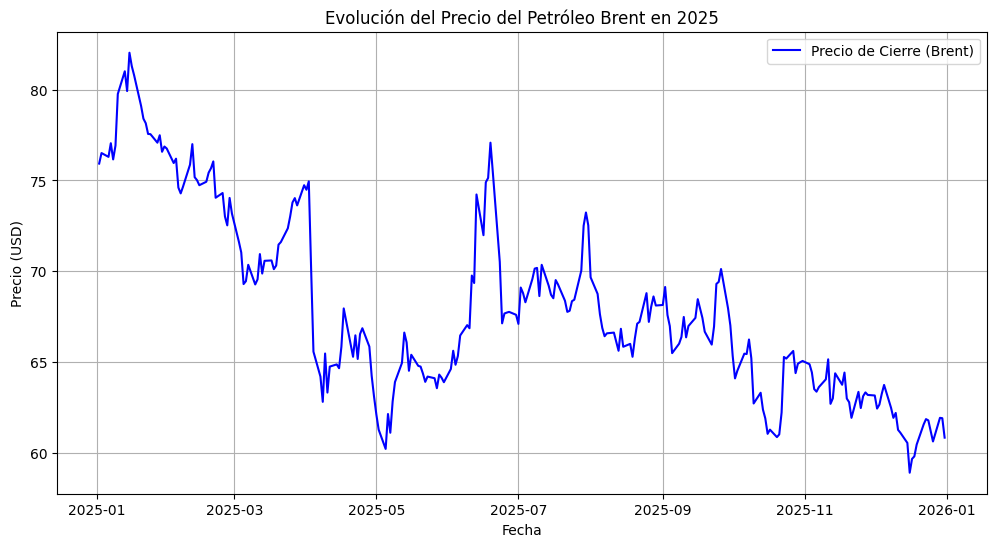

Precio al inicio de 2025: $75.93
Precio al cierre de 2025: $60.85
Rendimiento Total: -19.86%
Tendencia: Bajista (Bearish)


In [8]:
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Price'], label='Precio de Cierre (Brent)', color='blue')
plt.title('Evolución del Precio del Petróleo Brent en 2025')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.grid(True)
plt.legend()
plt.show()


# Aseguramos que esté ordenado por fecha
df = df.sort_values('Date')

precio_inicial = df.iloc[0]['Price']
precio_final = df.iloc[-1]['Price']
rendimiento_anual = ((precio_final - precio_inicial) / precio_inicial) * 100

print(f"Precio al inicio de 2025: ${precio_inicial}")
print(f"Precio al cierre de 2025: ${precio_final}")
print(f"Rendimiento Total: {rendimiento_anual:.2f}%")

if rendimiento_anual > 0:
    print("Tendencia: Alcista (Bullish)")
else:
    print("Tendencia: Bajista (Bearish)")

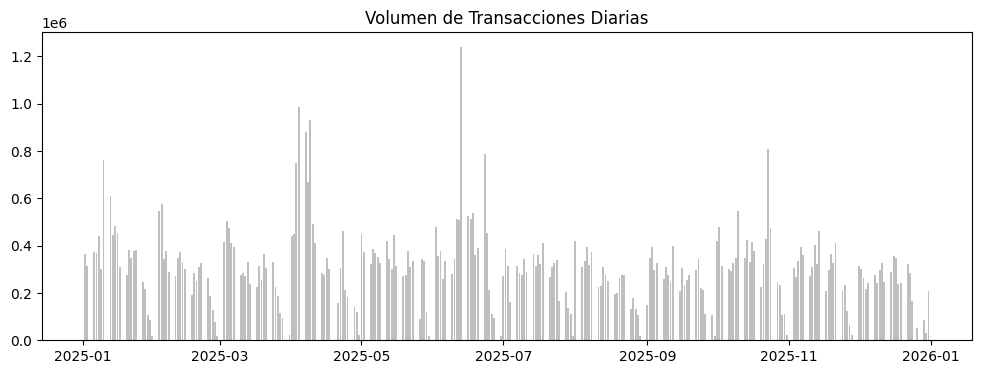

In [9]:
plt.figure(figsize=(12, 4))
plt.bar(df['Date'], df['Vol.'], color='gray', alpha=0.5)
plt.title('Volumen de Transacciones Diarias')
plt.show()

Text(0.5, 1.0, 'Distribución de los Cambios Porcentuales Diarios')

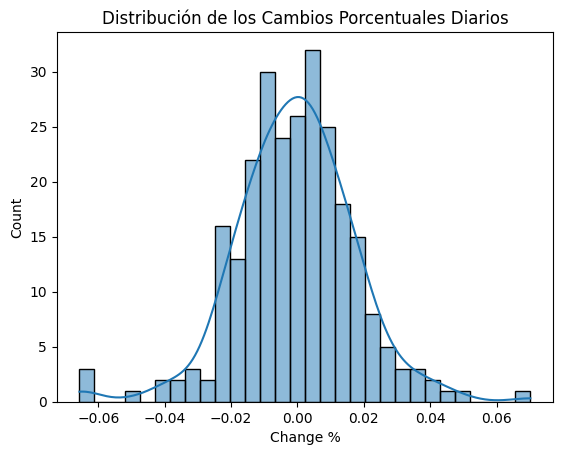

In [10]:
sns.histplot(df['Change %'], kde=True, bins=30)
plt.title('Distribución de los Cambios Porcentuales Diarios')

Text(0.5, 1.0, 'Mapa de Correlación de Variables')

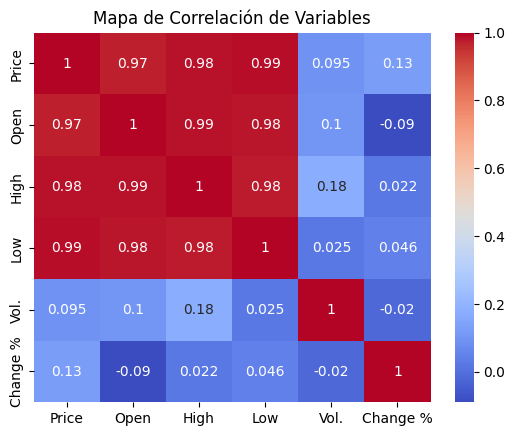

In [11]:
correlation = df[['Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlación de Variables')